In [7]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

In [8]:
file_path = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML\refund_sessions.csv"
df = pd.read_csv(file_path, low_memory=False)

In [9]:
df = df[df['session_dt']!="session_dt"]
df[df['session_dt'].isna()]
##print(df.head(10))

,session_id,session_dt,year1,month1,wk1,incident_id,customer_id,issue_type,sub_issue_type,sub_sub_issue_type,...,contact_to_complete_bucket,contact_to_SLA_bucket,init_completion_flag,pymnt_cnt,payment_type_final,RNK,contacts,inc_cnt,odr_cnt,acct_cnt


In [10]:
import missingno as msno
import matplotlib.pyplot as plt

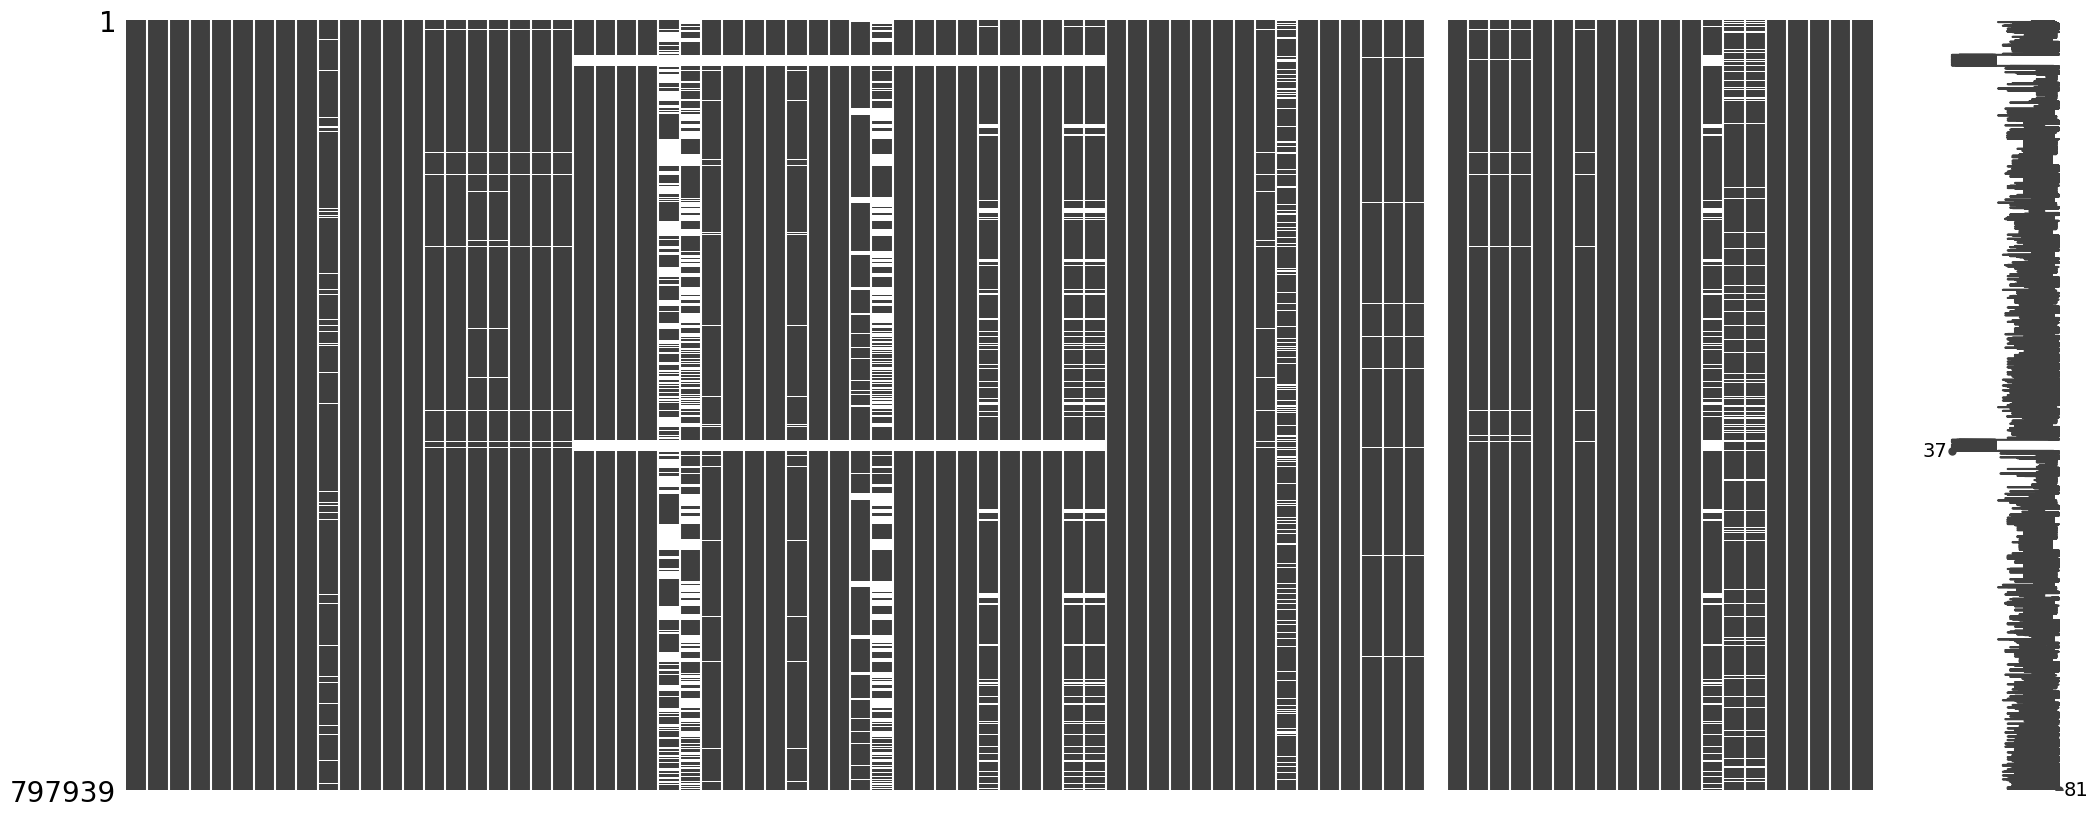

In [11]:
msno.matrix(df)
plt.show()


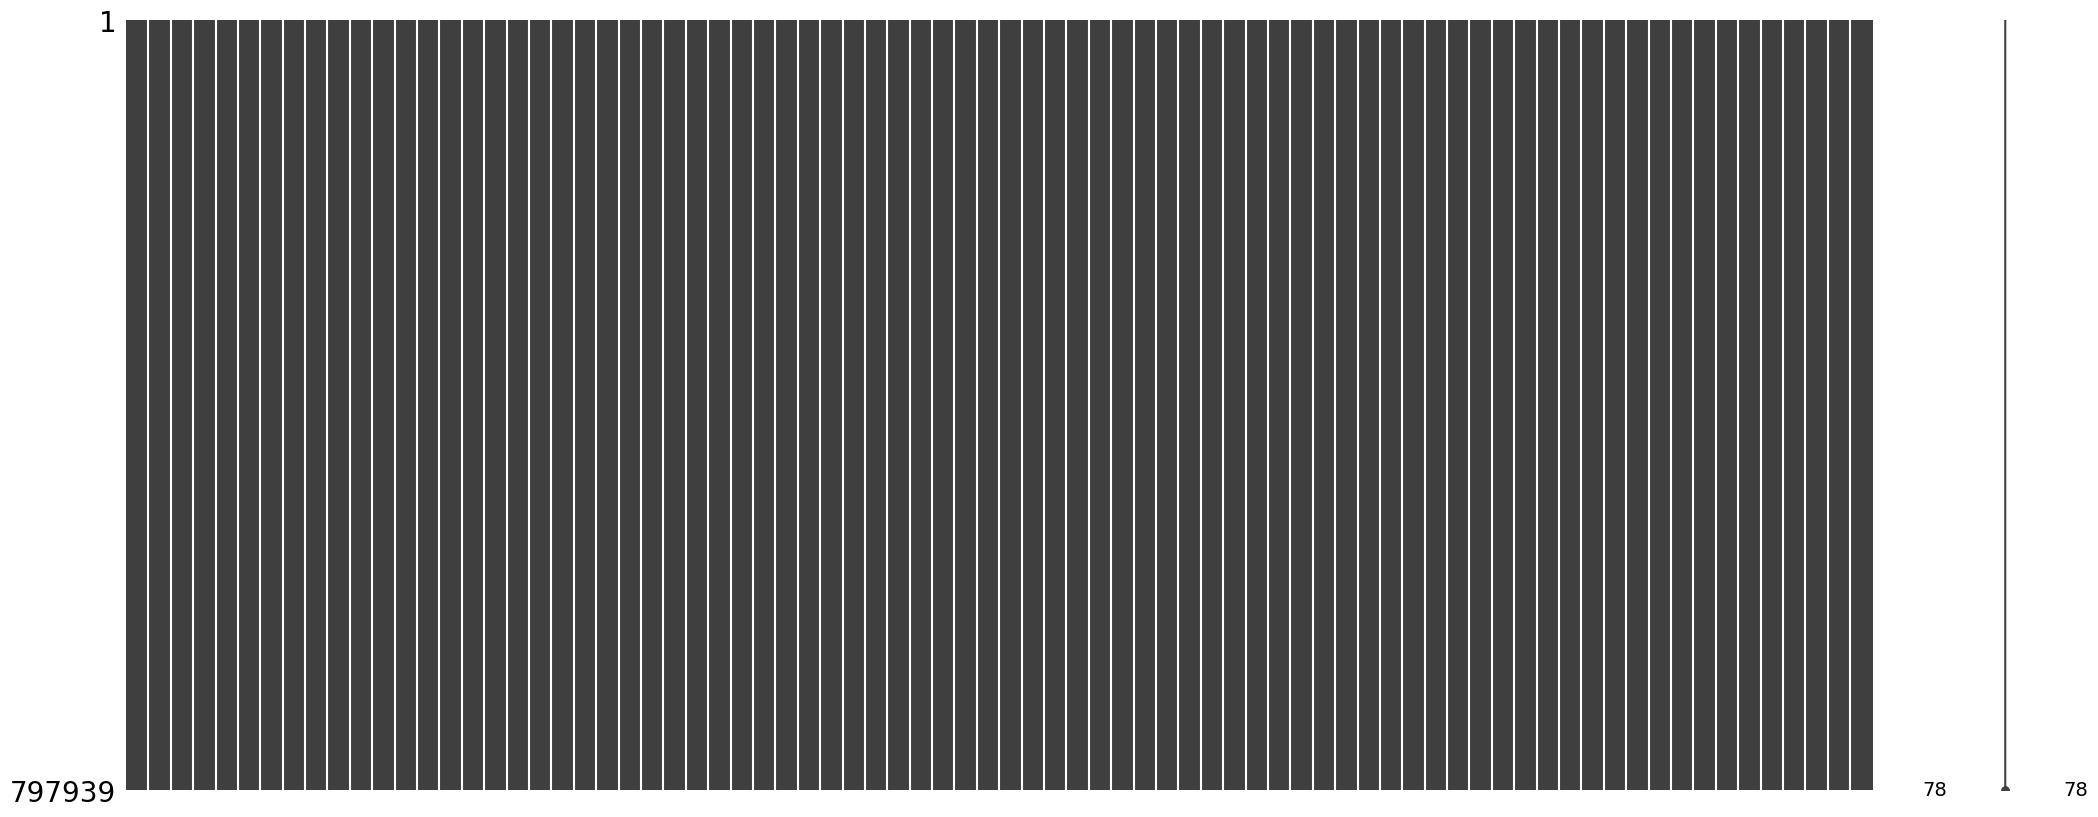

In [12]:
limit = len(df) *0.8
df=df.dropna(thresh=limit, axis=1)

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(-1)

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('unknown')

import missingno as msno
msno.matrix(df)
plt.show()

In [13]:
print(df.isnull().sum().sum())

0


In [9]:
print(df.columns)

Index(['session_id', 'session_dt', 'year1', 'month1', 'wk1', 'incident_id',
       'customer_id', 'issue_type', 'sub_issue_type', 'sub_sub_issue_type',
       'ssi', 'deliverygroup', 'LOB', 'FRM_OCR_Flag', 'order_external_id',
       'order_item_id', 'initial_promise_date_time', 'final_promise_date_time',
       'is_shopsy_order', 'marketplace_id', 'order_status', 'refund_status',
       'Refund_completion_flag', 'refund_final_status_updated', 'refund_mode',
       'payment_instrument', 'refund_reason', 'refund_reason_flag',
       'ref_amount_flag', 'transaction_source', 'ARN_ISSUE_FLAG', 'void_flag',
       'pg_id', 'order_id', 'parent_refund_id', 'child_refund_id',
       'parent_created_at', 'completed_time', 'Refund_completion_flag1',
       'delivery_tat_variance', 'created_completed_variance', 'refund_lag_Day',
       'refund_lag_hrs', 'is_rto', 'loyalty_segment', 'customer_value_segment',
       'total_orders_customers', 'total_incidents', 'SLA_First_breach',
       'SLA_last_b

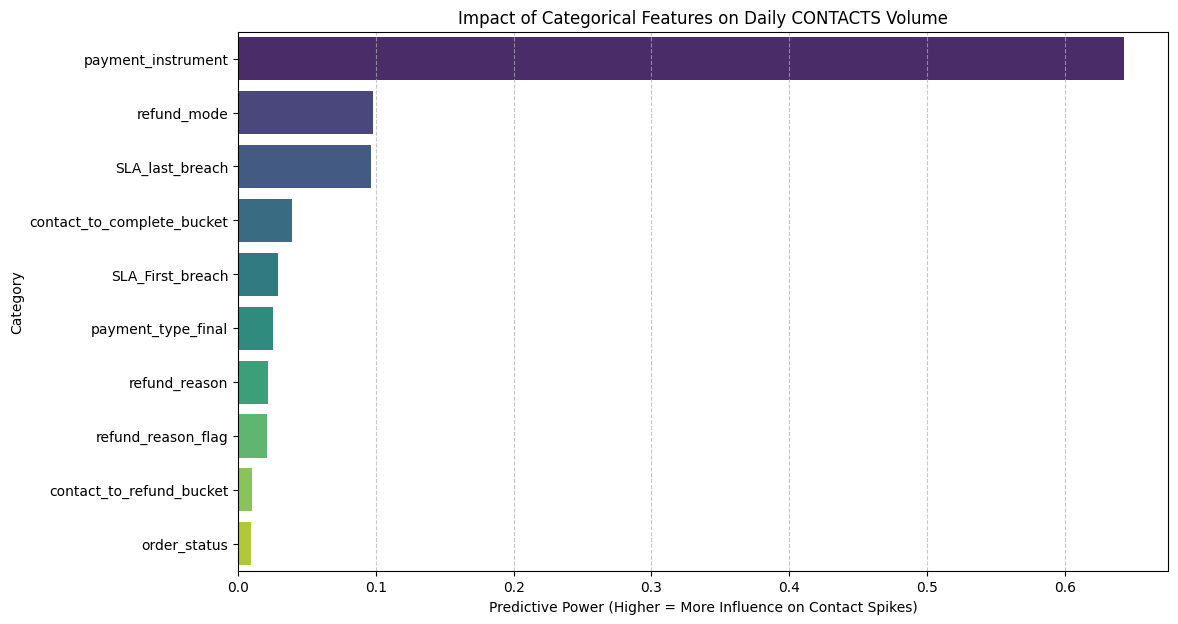

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing  import LabelEncoder
from importlib import reload

reload(plt)
target = 'contacts'
exclude = ['session_id', 'incident_id', 'order_external_id', 'ucid','year1', 'month1', 'wk1','order_id','customer_id','session_dt','report_date',
           'initial_promise_date_time','final_promise_date_time',target]
categorical_cols = [c for c in df.select_dtypes(include=['object']).columns if c not in exclude]
df_daily = df.groupby('session_dt').agg({
    'session_id': 'count',
    'daily_gmv': 'mean',
    'FCR_rate': 'mean'
}).rename(columns={'session_id': target})

for col in categorical_cols:
    df_daily[col]=df.groupby('session_dt')[col].agg(lambda x: x.mode()[0] if not x.mode().empty else "unknown")
    

df_ml = df_daily.copy()
encoder = LabelEncoder()
for col in categorical_cols:
    df_ml[col] = encoder.fit_transform(df_ml[col].astype(str))

X = df_ml[categorical_cols]
y = df_ml[target]

if len(df_daily) > 1:
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X,y)
    
    feat_impact=pd.DataFrame({
    'Category': categorical_cols,
    'Impact_Score': rf_model.feature_importances_
    }).sort_values(by='Impact_Score', ascending=False)

    plt.figure(figsize=(12,7))
    sns.barplot(
    x='Impact_Score',
    y='Category', 
    data=feat_impact.head(10), 
    hue='Category',
    palette='viridis',
    legend=False)

    plt.title(f"Impact of Categorical Features on Daily {target.upper()} Volume")
    plt.xlabel("Predictive Power (Higher = More Influence on Contact Spikes)")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Error: Not enough data points to train.")

In [11]:
ssi_payment_impact = df.groupby(['payment_instrument','ssi']).agg({
    'contacts': ['count', 'mean']
}).reset_index()

ssi_payment_impact_columns = ['payment_instrument','ssi','total_sessions','avg_contacts_per_session']
ssi_payment_impact.columns = ssi_payment_impact_columns
ssi_payment_impact = ssi_payment_impact.sort_values(by='avg_contacts_per_session', ascending=False)
print("Top 10 payment + SSI Combinations Driving Contact Increases:")
print(ssi_payment_impact.head(10))

Top 10 payment + SSI Combinations Driving Contact Increases:
  payment_instrument                                                ssi  \
0                COD  Refund Follow-ups->Gathered Offline Refund Det...   
1                COD  Refunds->Refund Related Enquiry->Refund Status...   
2                COD  Refunds->Refund Related Issues->Cancellation d...   
3                COD  Refunds->Refund Related Issues->Refund Failed/...   
4                COD  Refunds->Refund Related Issues->Refund complet...   
5                COD  Refunds->Refund Related Issues->Refund stuck_I...   
6                COD    Refunds->Refund Related Issues->Return Override   
7               COIN  Refund Follow-ups->Gathered Offline Refund Det...   
8               COIN  Refunds->Refund Related Enquiry->Refund Status...   
9               COIN  Refunds->Refund Related Issues->Cancellation d...   

   total_sessions  avg_contacts_per_session  
0           22552                       1.0  
1          145762    

In [12]:
print(df['wk1'].unique())

[45 41 44 48 40 42 50 43 49 51 47 52 46]


In [13]:
weekly_ssi_trend = df.groupby(['wk1','payment_instrument','ssi'])['contacts'].sum().unstack(level=0).fillna(0)
week_old =50
week_new = 51
comparison_name =f'%_Change_Wk{week_old}_to_Wk{week_new}'
weekly_ssi_trend[comparison_name] = (
    (weekly_ssi_trend[week_new] - weekly_ssi_trend[week_old]) /
    (weekly_ssi_trend[week_old] + 0.001)) *100


top_changes = weekly_ssi_trend.reset_index().sort_values(by=comparison_name, ascending=False)
print(f"Top % increase in contacts from Week {week_old} to {week_new}:")
print(top_changes[['payment_instrument', 'ssi', comparison_name]].head(10))

Top % increase in contacts from Week 50 to 51:
wk1 payment_instrument                                                ssi  \
56    FLIPKART_FINANCE  Refunds->Refund Related Enquiry->Refund Status...   
54              FK_UPI    Refunds->Refund Related Issues->Return Override   
66             PHONEPE  Refunds->Refund Related Enquiry->Refund Status...   
69             PHONEPE  Refunds->Refund Related Issues->Refund stuck_I...   
30                 EGV  Refunds->Refund Related Issues->Cancellation d...   
71                RTGS  Refunds->Refund Related Enquiry->Refund Status...   
64                 NET    Refunds->Refund Related Issues->Return Override   
25               DEBIT  Refunds->Refund Related Issues->Refund complet...   
44                 EMI  Refunds->Refund Related Issues->Refund Failed/...   
62                 NET  Refunds->Refund Related Issues->Refund complet...   

wk1  %_Change_Wk50_to_Wk51  
56           300000.000000  
54           200000.000000  
66           20000

In [14]:
multi_cat_impact = df.groupby(['wk1','payment_instrument','refund_mode','ssi'])['contacts'].sum().unstack(level=0).fillna(0)
week_old =51
week_new = 52
comparison_name =f'%_Change_Wk{week_old}_to_Wk{week_new}'
multi_cat_impact[comparison_name] = (
    (multi_cat_impact[week_new] - multi_cat_impact[week_old]) /
    (multi_cat_impact[week_old] + 0.001)) *100


top_changes = multi_cat_impact.reset_index().sort_values(by=comparison_name, ascending=False)
#print(f"Top % increase in contacts from Week {week_old} to {week_new}:")
##print(top_changes[['payment_instrument', 'ssi', comparison_name]].head(10))
print(top_changes.head(10))

wk1 payment_instrument refund_mode  \
139            PHONEPE        IMPS   
17                 COD      QC_EGV   
124   FLIPKART_FINANCE        IMPS   
86          EGV_WALLET  EGV_WALLET   
119             FK_UPI        IMPS   
118             FK_UPI        IMPS   
64               DEBIT        IMPS   
138            PHONEPE        IMPS   
58               DEBIT  DEBIT_CARD   
159        UPI_COLLECT        IMPS   

wk1                                                ssi     40     41     42  \
139  Refunds->Refund Related Issues->Refund Failed/...    0.0    2.0    0.0   
17   Refunds->Refund Related Issues->Refund stuck_I...    2.0    0.0    0.0   
124  Refunds->Refund Related Issues->Cancellation d...    0.0    0.0    0.0   
86   Refunds->Refund Related Issues->Refund Failed/...    1.0    5.0    4.0   
119  Refunds->Refund Related Issues->Refund Failed/...    1.0    4.0    4.0   
118  Refunds->Refund Related Issues->Cancellation d...    1.0    1.0    1.0   
64   Refunds->Refund Related

In [15]:
multi_cat_impact = df.groupby(['wk1','payment_instrument','refund_mode','ssi'])['contacts'].sum().unstack(level=0).fillna(0)
week_old =51
week_new = 52

abs_col = f'Delta_Wk{week_old}_to_{week_new}'
pct_col = f'%_Change_Wk{week_old}_to_{week_new}'

multi_cat_impact[abs_col]= multi_cat_impact[week_new] - multi_cat_impact[week_old]
multi_cat_impact[pct_col] = (
    (multi_cat_impact[week_new] - multi_cat_impact[week_old]) /
    (multi_cat_impact[week_old] + 0.001)) *100


top_impact = multi_cat_impact.reset_index().sort_values(by=pct_col, ascending=False)
print(f"Top infernces for Week {week_new} Vs {week_old}:")
print(top_impact[['payment_instrument','refund_mode', 'ssi', abs_col,pct_col]].head(10))
##print(top_changes.head(10))

Top infernces for Week 52 Vs 51:
wk1 payment_instrument refund_mode  \
139            PHONEPE        IMPS   
17                 COD      QC_EGV   
124   FLIPKART_FINANCE        IMPS   
86          EGV_WALLET  EGV_WALLET   
119             FK_UPI        IMPS   
118             FK_UPI        IMPS   
64               DEBIT        IMPS   
138            PHONEPE        IMPS   
58               DEBIT  DEBIT_CARD   
159        UPI_COLLECT        IMPS   

wk1                                                ssi  Delta_Wk51_to_52  \
139  Refunds->Refund Related Issues->Refund Failed/...               4.0   
17   Refunds->Refund Related Issues->Refund stuck_I...               2.0   
124  Refunds->Refund Related Issues->Cancellation d...               2.0   
86   Refunds->Refund Related Issues->Refund Failed/...               2.0   
119  Refunds->Refund Related Issues->Refund Failed/...               1.0   
118  Refunds->Refund Related Issues->Cancellation d...               1.0   
64   Refunds->Re

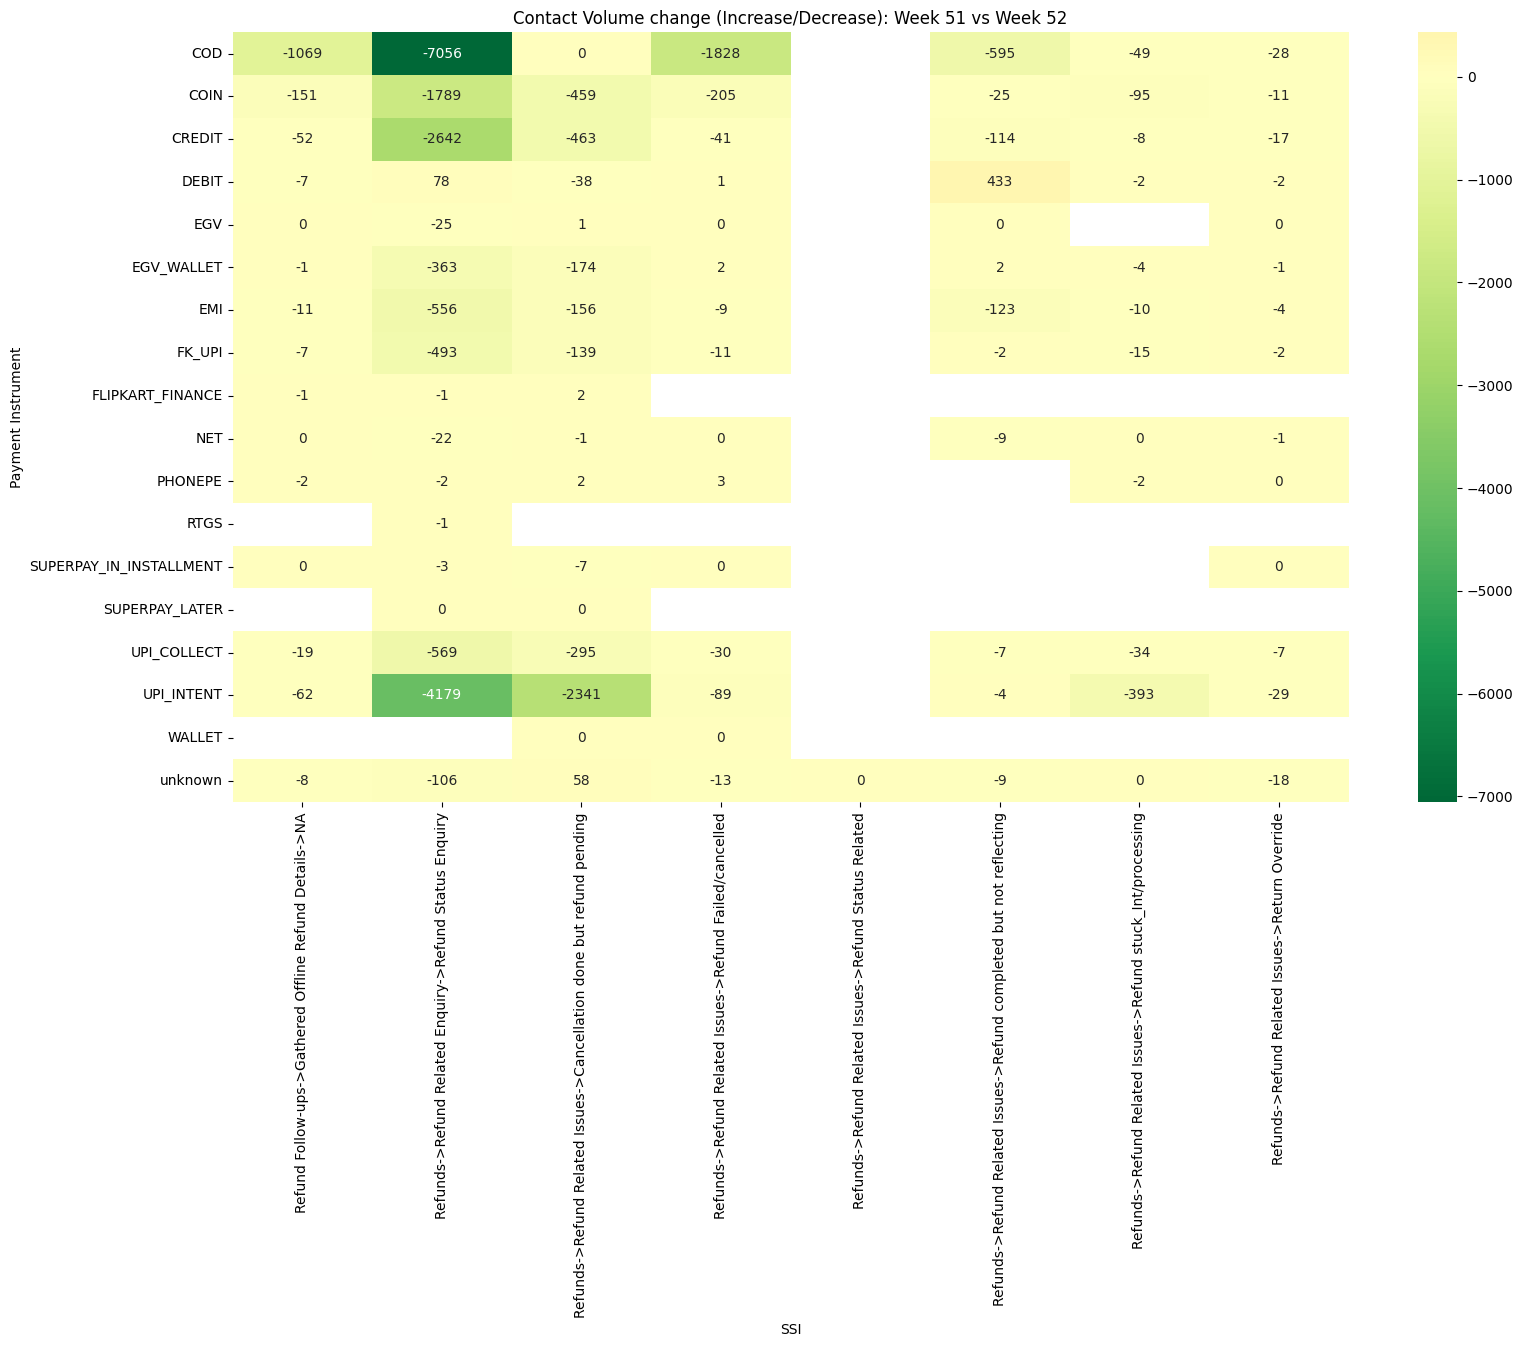

In [16]:
week_old =51
week_new = 52
comparison_name = f'Delta_Wk{week_old}_to_Wk{week_new}'
weekly_ssi_trend[comparison_name]=weekly_ssi_trend[week_new] - weekly_ssi_trend[week_old]
pivot_df= weekly_ssi_trend.reset_index()
pivot_delta = pivot_df.pivot(
    index='payment_instrument', 
    columns='ssi',
    values=comparison_name)
plt.figure(figsize=(18,10))
sns.heatmap(
    pivot_delta,
    annot=True,
    fmt=".0f",
    cmap='RdYlGn_r',
    center=0)
plt.title(f"Contact Volume change (Increase/Decrease): Week {week_old} vs Week {week_new}")
plt.xlabel("SSI")
plt.ylabel("Payment Instrument")
plt.show()

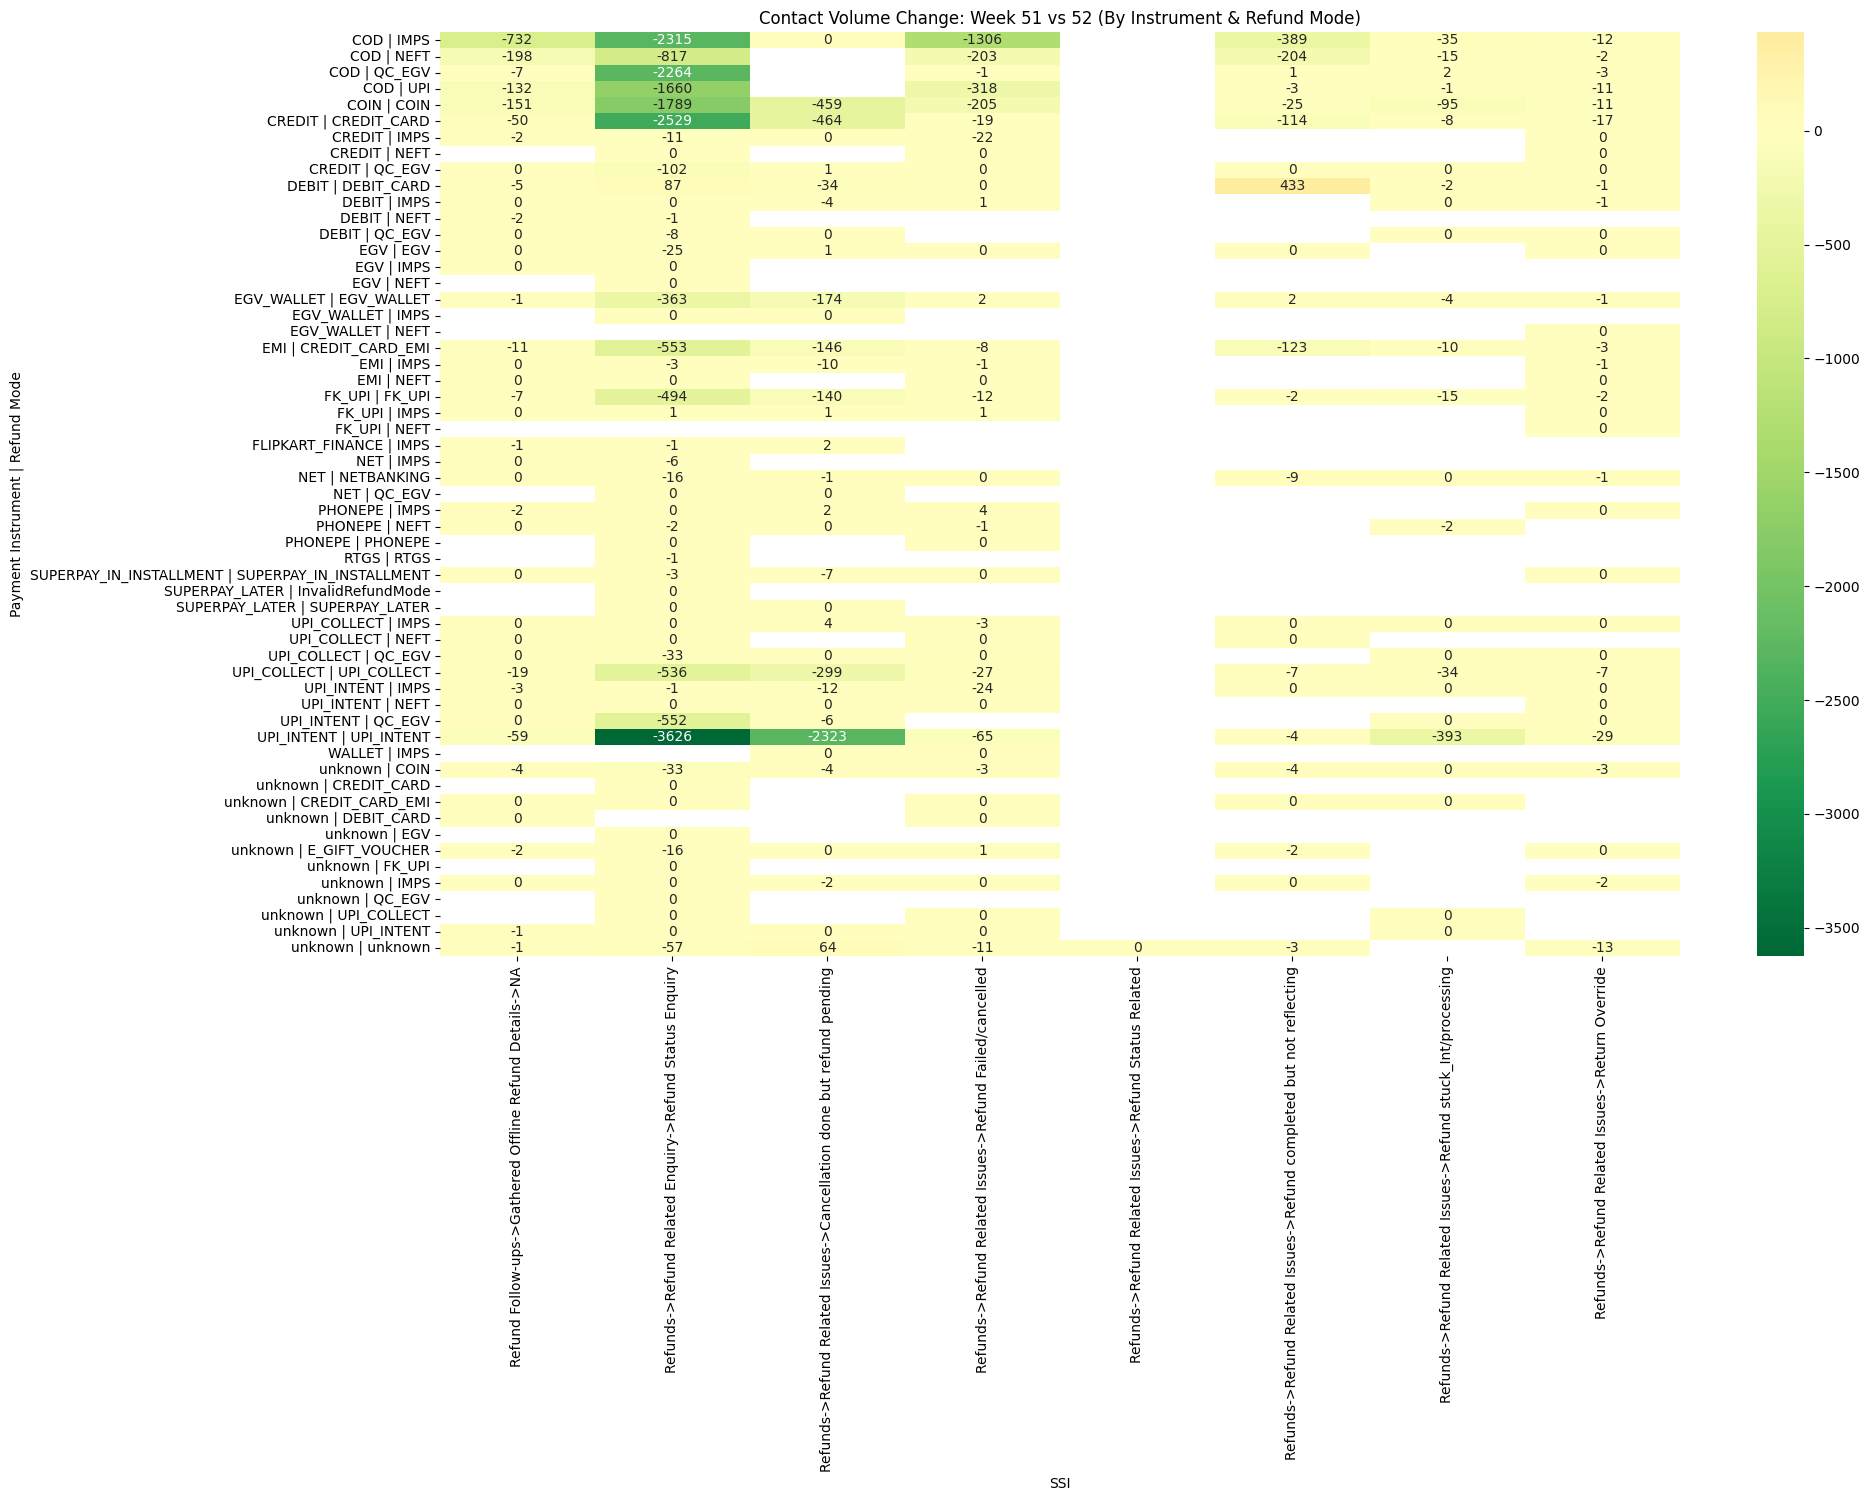

In [17]:
# 1. Recalculate the trend including refund_mode
weekly_trend = df.groupby(['wk1', 'payment_instrument', 'refund_mode', 'ssi'])['contacts'].sum().unstack(level=0).fillna(0)

# 2. Calculate the Delta
week_old, week_new = 51, 52
comparison_name = f'Delta_Wk{week_old}_to_{week_new}'
weekly_trend[comparison_name] = weekly_trend[week_new] - weekly_trend[week_old]

# 3. Flatten for the Heatmap
pivot_df = weekly_trend.reset_index()

# Combine Instrument and Mode for a detailed Y-axis label
pivot_df['Instrument_Mode'] = pivot_df['payment_instrument'] + " | " + pivot_df['refund_mode']

# 4. Pivot
pivot_delta = pivot_df.pivot(
    index='Instrument_Mode', 
    columns='ssi',
    values=comparison_name
)

# 5. Plot
plt.figure(figsize=(20, 12))
sns.heatmap(pivot_delta, annot=True, fmt=".0f", cmap='RdYlGn_r', center=0)

plt.title(f"Contact Volume Change: Week {week_old} vs {week_new} (By Instrument & Refund Mode)")
plt.xlabel("SSI")
plt.ylabel("Payment Instrument | Refund Mode")
plt.show()